### Análise do Log e contexto para alteração

1. **Física Controlada (`L_PDE` ≈ 1.88):**
* Isso é excelente. A mudança de peso (`0.001`) funcionou. A rede não está mais "brigando" com a matemática. O custo de obedecer à lei de Heston é baixo, então a rede tem liberdade para tentar ajustar o preço.

2. **Dados Altos (`L_Dat` ≈ 446.0):**
* Isso confirma que agora o **erro está sendo calculado em Reais (R$)** ao quadrado (ou escala similar), e não mais normalizado.
* \sqrt{446} \approx 21.1. Isso indica que, em média quadrática, o erro é de R$ 21,00. Porém, como o `MAE` é 3.28 e o `Bias` é -2.58, isso sugere que existem **alguns outliers gigantes** (provavelmente opções Deep ITM com valores nominais altos) que estão inflando o MSE, enquanto a média de erro (MAE) é mais comportada.

3. **O Problema do Viés (`Bias` ≈ -2.58):**
* **Diagnóstico:** O modelo está prevendo, em média, R$ 2,58 a menos que o mercado.
* **Interpretação:** O modelo aprendeu o **Valor Intrínseco** (Payoff: S - K), mas ainda **não aprendeu o Valor Extrínseco** (Valor no Tempo: Volatilidade * Tempo).
* Como a rede neural começa com pesos pequenos (próximos de zero), a saída da rede `pricing_net` tende a zero.
* Sua fórmula de Hard Constraint é: Preço = Payoff + (1 - e^{-T}) \times Rede(x).
* Se `Rede(x) ≈ 0`, então Preço \approx Payoff.
* No mercado, Preço = Payoff + ValorTemporal. Logo, Preço_{modelo} - Preço_{mercado} \approx -ValorTemporal. É exatamente isso que estamos vendo: o viés negativo é o valor do tempo que a rede ainda não "acordou" para prever.


4. **O Parâmetro `Bias_Param` (-0.0597):**
* O fato de ele estar negativo é preocupante. O modelo deveria estar aprendendo um viés *positivo* para compensar a falta de prêmio. Se ele está negativo, pode indicar que em alguma região (talvez OTM), o modelo está tentando reduzir o preço excessivamente.

---

### O que foi feito?


#### Opção A: Sem ter feito a modificação

* O `L_Dat` caiu de 463 para 446. Está lento, mas está caindo.
* Se você tiver tempo, deixe rodar até o final da Fase 4. É possível que, de repente, o gradiente encontre o caminho e o `Bias` comece a subir rapidamente.

Os resultados de ter mantido o treinamento deste modo gerou os seguintes resultados:

#### Curva de preço 

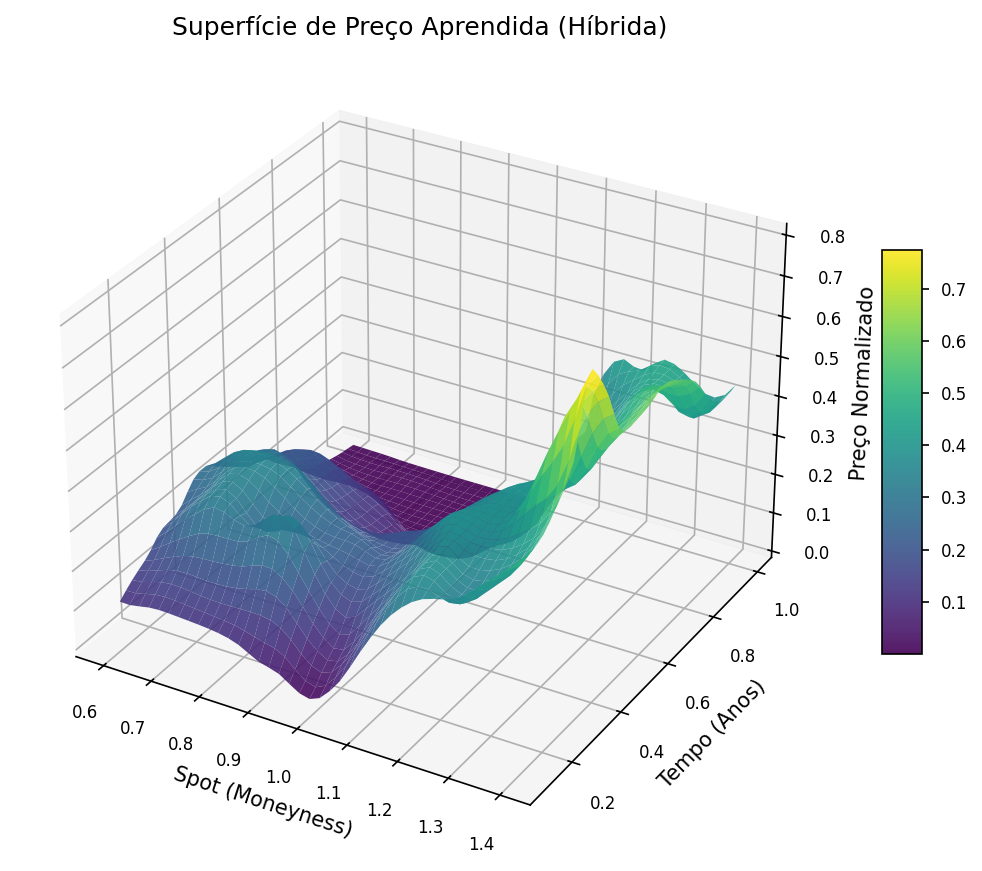


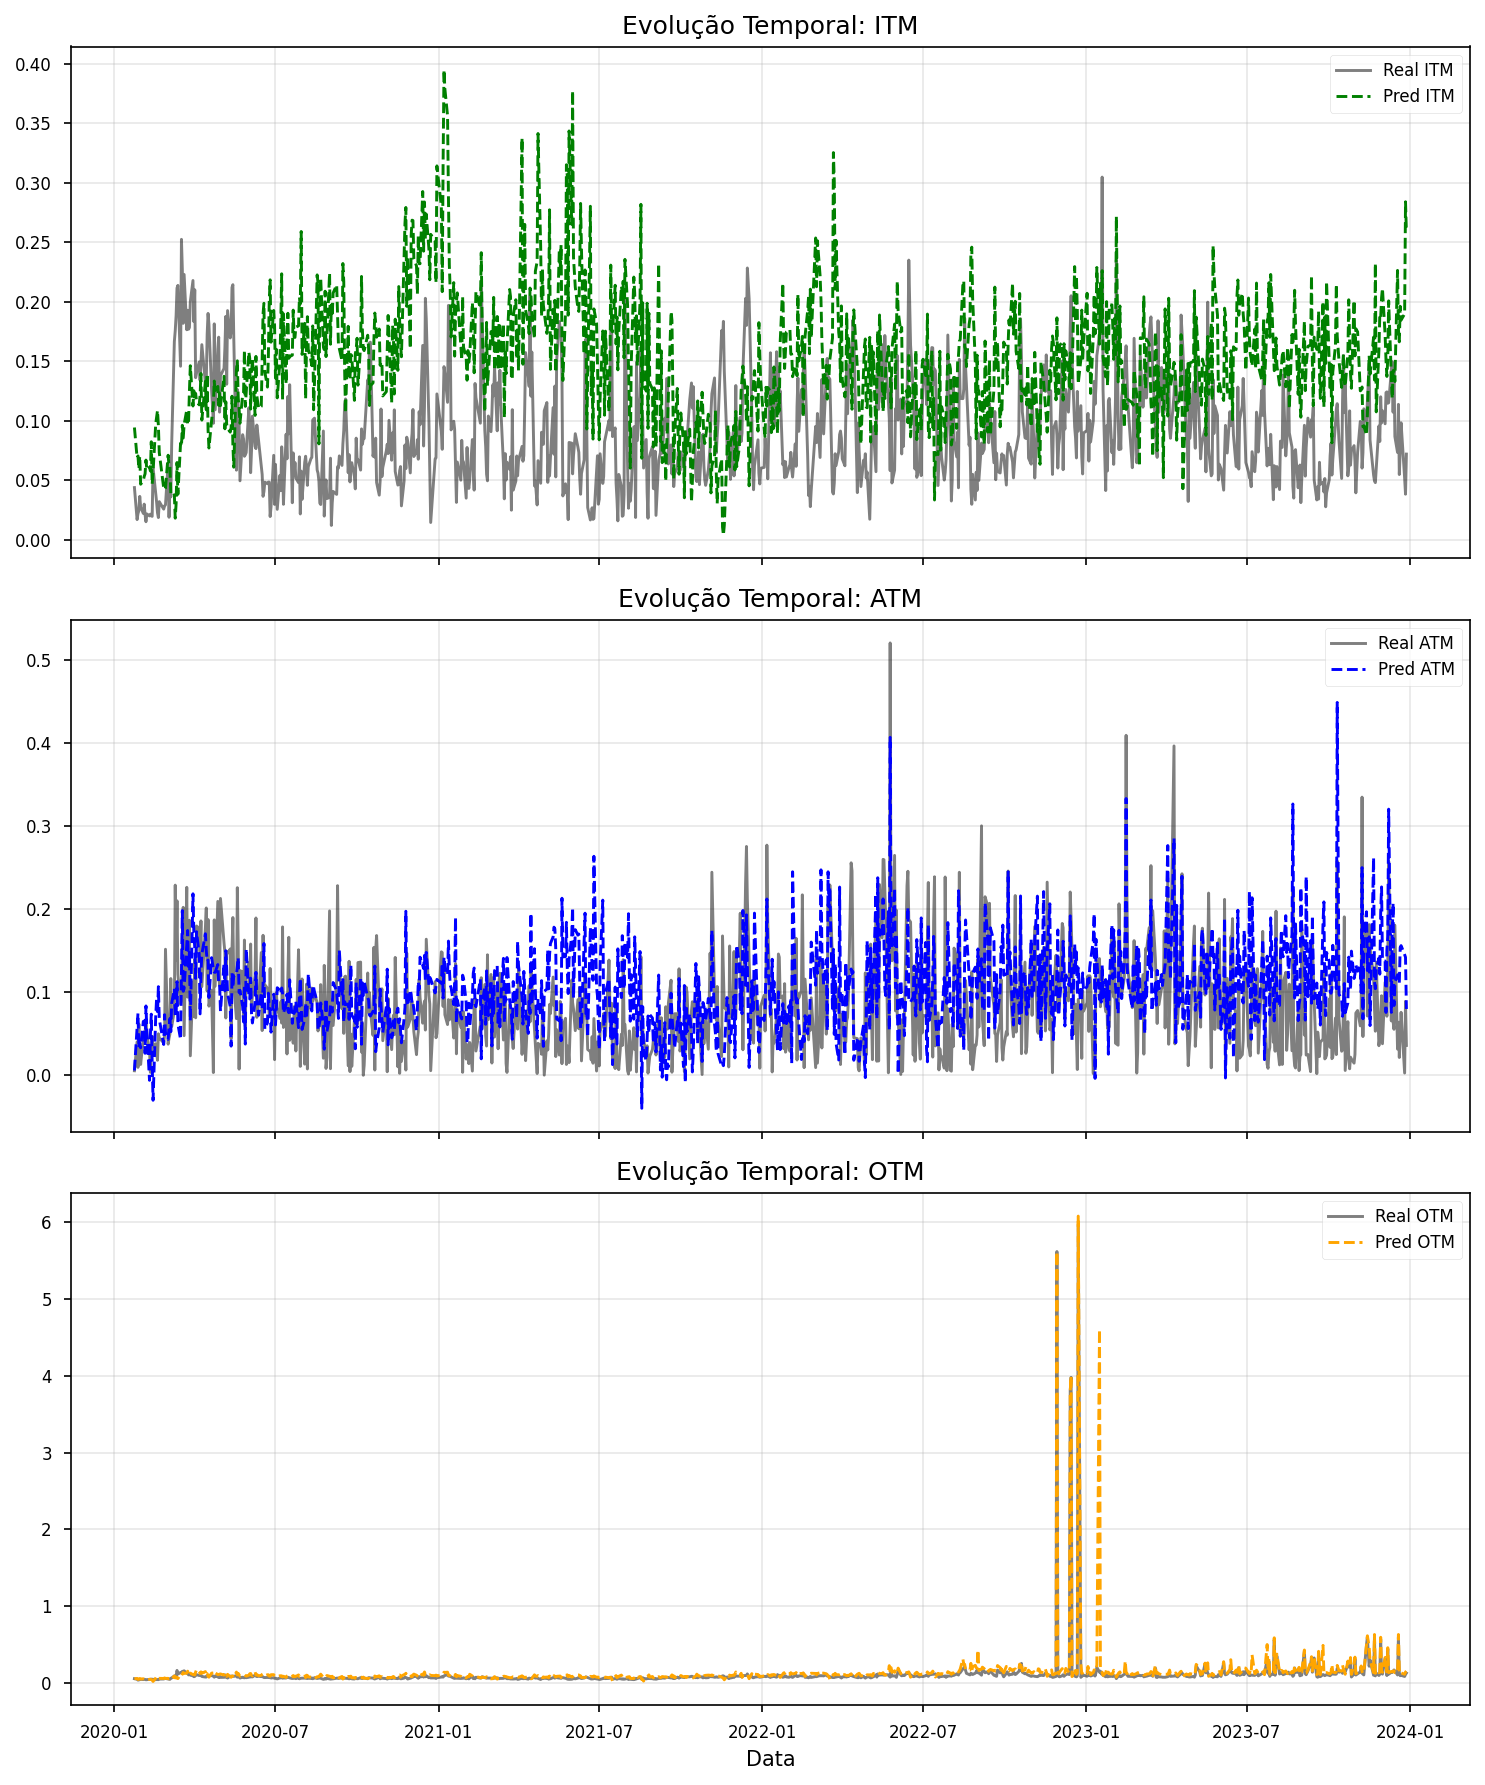



#### Opção B: Intervenção Cirúrgica (Recomendado se estagnar novamente)

Se o `Bias` continuar travado em -2.5 ou -2.6 por mais 50 épocas, significa que a rede caiu num **Mínimo Local** (ela acha mais seguro prever zero de valor temporal do que arriscar errar a física).

Para corrigir isso no próximo treino (pare este se não melhorar em 10 min), faça estas 3 alterações rápidas no `src/model.py`:

**1. Garantir Positividade da Saída (Time Value)**
Verifique a última camada da `pricing_net` em `src/model.py`. Ela **deve** ter uma ativação `Softplus` para garantir que o Valor Temporal nunca seja negativo (o que puxaria o viés para baixo).

```python
# No forward da classe DeepHestonHybrid (ou PricingNet):
# Errado (Linear permite valor negativo):
# time_value_raw = self.pricing_net(features)

# Correto (Força valor positivo):
time_value_raw = torch.nn.functional.softplus(self.pricing_net(features))

```

**2. Inicialização "Quente" do Viés**
Se você estiver usando uma variável `self.price_bias` ou similar, inicialize-a com um valor positivo alto (ex: 2.0 ou 3.0) em vez de 0.0. Isso "empurra" o modelo para cima logo no começo.

```python
# No __init__ do model.py
self.price_bias = nn.Parameter(torch.tensor([2.0])) # Começa chutando +2 reais

```

**3. Remoção de Outliers na Loss (Trainer)**
Como o MSE (`L_Dat`=446) está muito alto devido a opções caras, o gradiente fica instável. Mude a Loss para **MAE (L1Loss)** ou **Huber Loss** no `src/trainer.py`. Elas são menos sensíveis a outliers.

```python
# Em src/trainer.py -> compute_loss
# Em vez de MSE (quadrático):
# loss_data = torch.mean(weights * (pred_real - target_real)**2)

# Use Huber Loss (SmoothL1):
loss_data = torch.nn.functional.smooth_l1_loss(pred_real, target_real, reduction='none')
loss_data = torch.mean(weights * loss_data)

```

**Resumo:**
O log mostra que o sistema está saudável (física ok), mas "preguiçoso" (só prevê o intrínseco). Se não destravar nas próximas 50 épocas, a solução é mudar a Loss para `SmoothL1` e garantir que a saída da rede seja estritamente positiva (`Softplus`).